---
## Data Analysis Pipeline — Pattern Matching amb SPARQL

A continuació implementem **4 queries SPARQL** que demostren el valor del model de graf per analitzar accidents de trànsit a Barcelona. Cada query representa un **patró analític diferent**:

| Query | Patró | Valor analític |
|---|---|---|
| Q1 | Accidents mortals per districte | Identificar zones de risc alt |
| Q2 | Perfil de conductor en accidents greus | Segment de risc per edat/sexe |
| Q3 | Accidents per torn del dia | Patrons temporals |
| Q4 | Tipus de vehicle més involucrat per barri | Planificació d'infraestructura |

### Funció auxiliar per executar i mostrar queries

In [13]:
from rdflib import Graph, Namespace
from rdflib.namespace import XSD
import pandas as pd
import matplotlib.pyplot as plt

In [14]:

WP   = Namespace("http://webprotege.stanford.edu/")
DATA = Namespace("http://data.bcn.cat/accidentes/")

g = Graph()
g.bind("wp", WP)
g.bind("data", DATA)
g.parse("kg_accidentes_bcn.ttl")

<Graph identifier=N0f9a9ad1d1864b7fab1f07e174d05de4 (<class 'rdflib.graph.Graph'>)>

In [4]:
def run_sparql(query_str, title=""):
    """Executa una query SPARQL sobre el graf i retorna un DataFrame."""
    results = g.query(query_str)
    cols = [str(v) for v in results.vars]
    rows = [[str(val) if val is not None else None for val in row] for row in results]
    df = pd.DataFrame(rows, columns=cols)
    if title:
        print(f"\n{'='*60}")
        print(f"  {title}")
        print(f"  {len(df)} resultats")
        print(f"{'='*60}")
    return df

### Q1 — Accidents mortals per districte

**Patró:** `AccidenteMortal → UbicadoEn → Lugar [Distrito]`

Identifica quins districtes de Barcelona concentren més accidents amb víctimes mortals.

In [15]:
Q1 = """
PREFIX wp:   <http://webprotege.stanford.edu/>
PREFIX data: <http://data.bcn.cat/accidentes/>

SELECT ?districte (COUNT(?acc) AS ?num_accidents_mortals)
WHERE {
    ?acc a wp:R8bzivJwhQYj45eHewQTg08 .   # AccidenteMortal
    ?acc wp:Ro80knf6kx29DunELcteYN ?lloc . # UbicadoEn
    ?lloc wp:R8VCcKl4uCPbHDX8to2A5w8 ?districte . # Distrito
}
GROUP BY ?districte
ORDER BY DESC(?num_accidents_mortals)
"""

df_q1 = run_sparql(Q1, "Q1 — Accidents mortals per districte")
df_q1["num_accidents_mortals"] = df_q1["num_accidents_mortals"].astype(int)
df_q1


  Q1 — Accidents mortals per districte
  6 resultats


,districte,num_accidents_mortals
0,Gràcia,3
1,Eixample,3
2,Sarrià-Sant Gervasi,2
3,Sant Martí,1
4,Sant Andreu,1
5,Horta-Guinardó,1


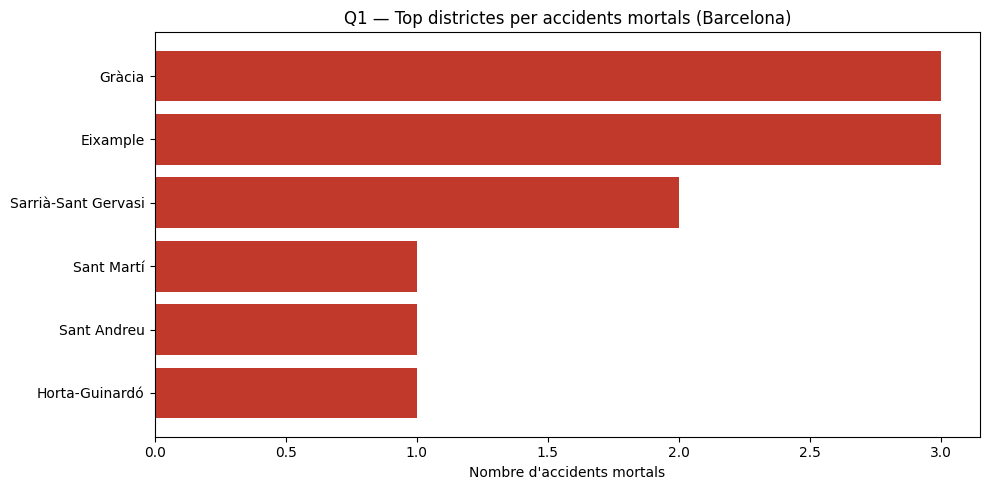

✓ Gràfic guardat


In [16]:


if not df_q1.empty:
    top10 = df_q1.head(10)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top10["districte"], top10["num_accidents_mortals"], color="#c0392b")
    ax.set_xlabel("Nombre d'accidents mortals")
    ax.set_title("Q1 — Top districtes per accidents mortals (Barcelona)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("q1_accidents_mortals_districte.png", dpi=150)
    plt.show()
    print("✓ Gràfic guardat")

### Q2 — Perfil del conductor en accidents greus

**Patró:** `Conductor → InvolucradoEn → AccidenteGrave` + `[Edad, Sexo, VehicleImplicat]`

Mostra l'edat, sexe i vehicle dels conductors involucrats en accidents greus. Útil per identificar segments de risc.

In [17]:
Q2 = """
PREFIX wp:   <http://webprotege.stanford.edu/>

SELECT ?edat ?sexe ?vehicle (COUNT(*) AS ?count)
WHERE {
    ?persona a wp:RBPXhVTcni9UaQtHolrwEGM .          # Conductor
    ?persona wp:Rqp27L1N9oTZweWd4AbJKw ?acc .         # InvolucradoEn
    ?acc     a wp:RYqhWnA3Yc3qHHEFBZcRoJ .            # AccidenteGrave
    ?persona wp:RCsWF1rtGUwHlrCw2nFCiyE ?edat .       # Edad
    ?persona wp:RDEVg1ttXmeqGODajUtvvgq ?sexe .       # Sexo
    OPTIONAL { ?persona wp:R94iV1JYRs5IqQSGPTpJbM8 ?vehicle } # VehicleImplicat
}
GROUP BY ?edat ?sexe ?vehicle
ORDER BY DESC(?count)
LIMIT 30
"""

df_q2 = run_sparql(Q2, "Q2 — Perfil del conductor en accidents greus")
df_q2["count"] = df_q2["count"].astype(int)
df_q2["edat"]  = pd.to_numeric(df_q2["edat"], errors="coerce")
df_q2


  Q2 — Perfil del conductor en accidents greus
  30 resultats


,edat,sexe,vehicle,count
0,46,H,Motocicleta,6
1,24,H,Turisme,5
2,37,H,Turisme,5
3,25,H,Motocicleta,5
4,57,H,Motocicleta,5
5,56,H,Motocicleta,5
6,40,H,Motocicleta,5
7,23,H,Motocicleta,5
8,51,H,Motocicleta,5
9,41,H,Motocicleta,5


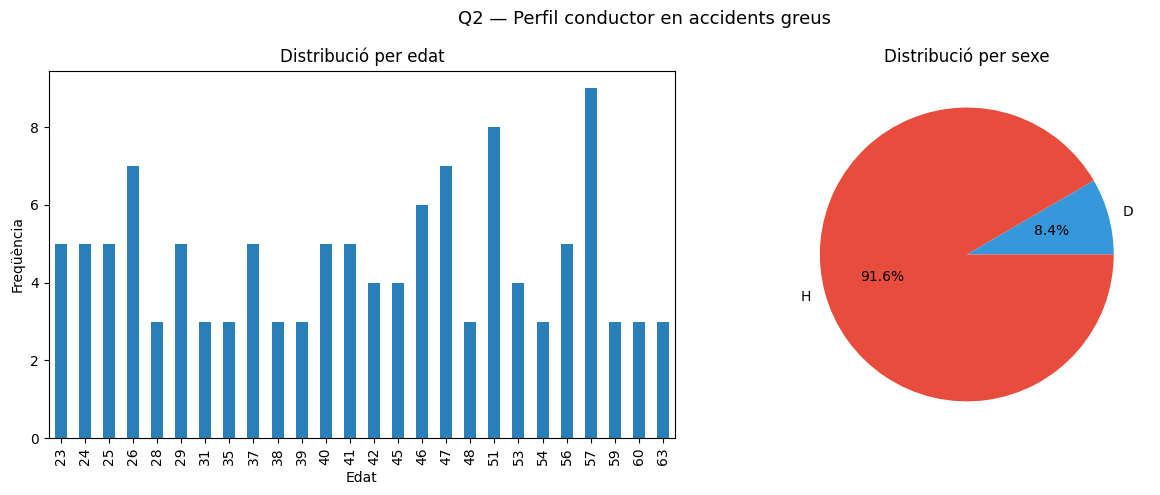

In [8]:
if not df_q2.empty and "edat" in df_q2.columns and "sexe" in df_q2.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Distribució per edat
    df_q2.groupby("edat")["count"].sum().plot(kind="bar", ax=axes[0], color="#2980b9")
    axes[0].set_title("Distribució per edat")
    axes[0].set_xlabel("Edat")
    axes[0].set_ylabel("Freqüència")

    # Distribució per sexe
    df_q2.groupby("sexe")["count"].sum().plot(kind="pie", ax=axes[1],
                                               autopct="%1.1f%%", colors=["#3498db","#e74c3c","#95a5a6"])
    axes[1].set_title("Distribució per sexe")
    axes[1].set_ylabel("")

    plt.suptitle("Q2 — Perfil conductor en accidents greus", fontsize=13)
    plt.tight_layout()
    plt.savefig("q2_perfil_conductor.png", dpi=150)
    plt.show()

### Q3 — Distribució d'accidents per torn del dia i gravetat

**Patró:** `Accidente [tipus] → FechadoEn [hora]`

Explota la relació temporal del graf per veure si la gravetat dels accidents varia amb el torn del dia.

In [9]:
Q3 = """
PREFIX wp:   <http://webprotege.stanford.edu/>

SELECT ?tipus_accident ?hora (COUNT(?acc) AS ?count)
WHERE {
    ?acc a ?tipus_accident .
    ?acc wp:R8BfMxHvuSS21BCIoJe4qQ8 ?data_hora .  # FechadoEn
    BIND(xsd:integer(SUBSTR(?data_hora, 12, 2)) AS ?hora)
    FILTER (?tipus_accident IN (
        wp:R7oZUszqj7aEjlsk698JmFM,   # AccidenteLeve
        wp:RYqhWnA3Yc3qHHEFBZcRoJ,   # AccidenteGrave
        wp:R8bzivJwhQYj45eHewQTg08    # AccidenteMortal
    ))
}
GROUP BY ?tipus_accident ?hora
ORDER BY ?hora
"""

df_q3 = run_sparql(Q3, "Q3 — Accidents per hora del dia i gravetat")

# Mapeig URI → nom llegible
tipus_map = {
    "http://webprotege.stanford.edu/R7oZUszqj7aEjlsk698JmFM": "Leve",
    "http://webprotege.stanford.edu/RYqhWnA3Yc3qHHEFBZcRoJ":  "Greu",
    "http://webprotege.stanford.edu/R8bzivJwhQYj45eHewQTg08":  "Mortal",
}
df_q3["tipus_accident"] = df_q3["tipus_accident"].map(tipus_map).fillna(df_q3["tipus_accident"])
df_q3["hora"]  = pd.to_numeric(df_q3["hora"],  errors="coerce")
df_q3["count"] = pd.to_numeric(df_q3["count"], errors="coerce")
df_q3


  Q3 — Accidents per hora del dia i gravetat
  55 resultats


,tipus_accident,hora,count
0,Leve,0,92
1,Greu,0,6
2,Leve,1,65
3,Greu,1,4
4,Mortal,1,1
5,Greu,2,4
6,Leve,2,46
7,Leve,3,31
8,Leve,4,46
9,Greu,4,1


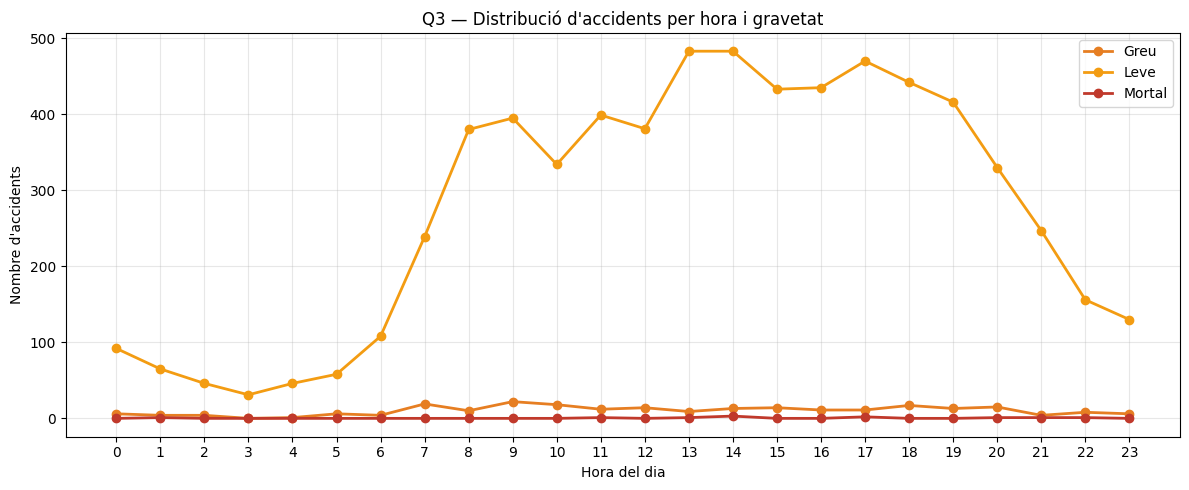

In [10]:
if not df_q3.empty:
    pivot = df_q3.pivot_table(index="hora", columns="tipus_accident", values="count", aggfunc="sum").fillna(0)
    colors = {"Leve": "#f39c12", "Greu": "#e67e22", "Mortal": "#c0392b"}

    fig, ax = plt.subplots(figsize=(12, 5))
    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col], marker="o", label=col,
                color=colors.get(col, None), linewidth=2)
    ax.set_xlabel("Hora del dia")
    ax.set_ylabel("Nombre d'accidents")
    ax.set_title("Q3 — Distribució d'accidents per hora i gravetat")
    ax.legend()
    ax.set_xticks(range(0, 24))
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("q3_accidents_hora.png", dpi=150)
    plt.show()

### Q4 — Vianants atropellats: barris amb més víctimes

**Patró:** `Vianant → InvolucradoEn → Accidente → UbicadoEn → Lugar [Barrio]`

Cadena de 3 salts en el graf que seria molt més complicada en SQL. Identifica els barris amb més atropellaments.

In [11]:
Q4 = """
PREFIX wp:   <http://webprotege.stanford.edu/>

SELECT ?barri (COUNT(?vianant) AS ?num_atropellaments)
WHERE {
    ?vianant a wp:RBjMNvYweizmQ8EE1HnWwNF .        # Vianant
    ?vianant wp:Rqp27L1N9oTZweWd4AbJKw ?acc .       # InvolucradoEn
    ?acc     wp:Ro80knf6kx29DunELcteYN ?lloc .       # UbicadoEn
    ?lloc    wp:RCJq0kcAKOAezhCOBeEqGlT ?barri .     # Barrio
}
GROUP BY ?barri
ORDER BY DESC(?num_atropellaments)
LIMIT 15
"""

df_q4 = run_sparql(Q4, "Q4 — Barris amb més atropellaments de vianants")
df_q4["num_atropellaments"] = df_q4["num_atropellaments"].astype(int)
df_q4


  Q4 — Barris amb més atropellaments de vianants
  15 resultats


,barri,num_atropellaments
0,la Dreta de l'Eixample,112
1,la Nova Esquerra de l'Eixample,55
2,el Fort Pienc,46
3,la Sagrada Família,43
4,Sant Antoni,36
5,Sant Andreu,36
6,el Raval,35
7,Sants,30
8,Sant Gervasi - Galvany,28
9,les Corts,28


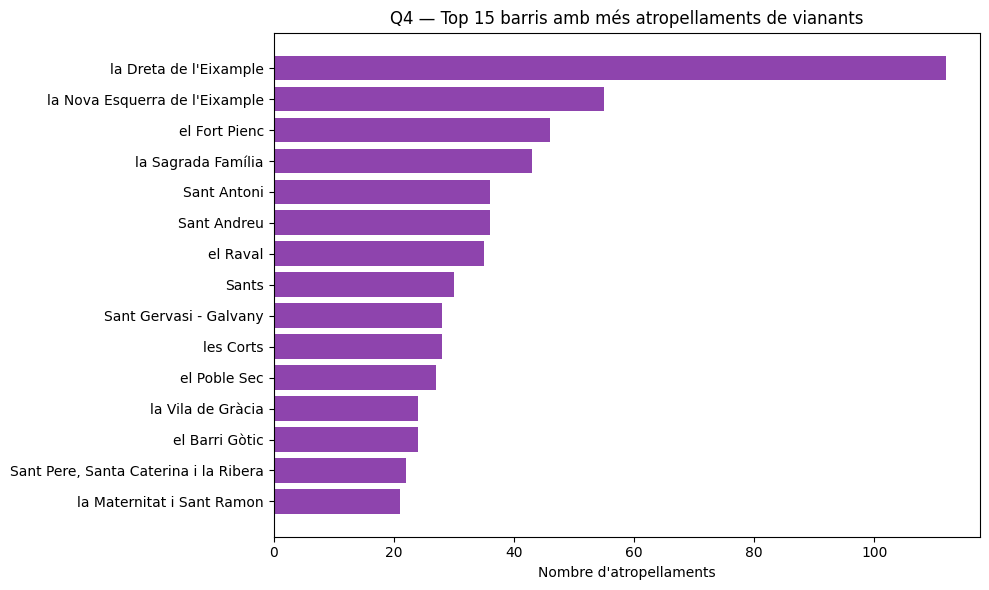

In [12]:

if not df_q4.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_q4["barri"], df_q4["num_atropellaments"], color="#8e44ad")
    ax.set_xlabel("Nombre d'atropellaments")
    ax.set_title("Q4 — Top 15 barris amb més atropellaments de vianants")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("q4_atropellaments_barri.png", dpi=150)
    plt.show()